In [ ]:
!pip install faker
!pip install tensorflow
import numpy as np
import pandas as pd
from faker import Faker
import hashlib
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, LSTM
from tensorflow import keras
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MASKING DATASET VTU19484 MAJOR.csv')

In [ ]:
print(data.head())
print(data.describe())

   Social_Security_Number  Credit_Number     DOB  \
0                     648          94107  1760.0   
1                     406          94114  1763.0   
2                     329            432  1740.0   
3                     753          94103  1735.0   
4                     574          94612  1605.6   

   Privacy_Policy_Reference_Number  Medical_Record  Data_Masking_Entity  \
0                          1825.90         1145.20             471784.0   
1                          1805.97         1207.60             443899.0   
2                          1766.69         1199.85             407935.0   
3                          1749.32         1143.80             383200.0   
4                          1621.51         1161.40             366168.0   

   Encryption_Key  Encryption_Method_SSN  Image_ID  Mask_ID  ...  Maskexists  \
0             457                  94107         1      101  ...       False   
1             424                  94114         2      102  ...       False

In [ ]:
fake = Faker()
def substitute_with_fake(value, dtype):
    if dtype == 'ssn':
        return fake.ssn()
    elif dtype == 'name':
        return fake.name()
    elif dtype == 'address':
        return fake.address()
    elif dtype == 'dob':
        return fake.date_of_birth().strftime("%Y-%m-%d")
    else:
        return "REDACTED"

def partial_mask(val):
    val_str = str(int(float(val))) if pd.notnull(val) else ""
    return val_str[:2] + "*" * (len(val_str) - 2) if len(val_str) > 2 else "*" * len(val_str)

def redact_value(val):
    return "***REDACTED***"

def tokenize(val):
    return hashlib.sha256(str(val).encode()).hexdigest()[:10]  # irreversible

def shuffle_column(col):
    shuffled = col.sample(frac=1).values
    return pd.Series(shuffled, index=col.index)


masked_data = data.copy()


for col in masked_data.columns:
    if 'SSN' in col or 'Social_Security_Number' in col:
        masked_data[col] = masked_data[col].apply(partial_mask)
    elif 'Credit' in col or 'DOB' in col:
        masked_data[col] = masked_data[col].apply(redact_value)
    elif 'Medical_Record' in col or 'FileID' in col:
        masked_data[col] = masked_data[col].apply(tokenize)
    elif 'Name' in col or 'Policy' in col:
        masked_data[col] = masked_data[col].apply(lambda x: substitute_with_fake(x, 'name'))
    elif 'Image_ID' in col or 'Mask_ID' in col or 'Facemask_ID' in col:
        masked_data[col] = masked_data[col].apply(partial_mask)
    elif 'Coordinates' in col or 'width' in col or 'height' in col:
        masked_data[col] = shuffle_column(masked_data[col])
    elif masked_data[col].dtype == 'object':
        masked_data[col] = masked_data[col].apply(lambda x: substitute_with_fake(x, 'text'))
    else:
        masked_data[col] = masked_data[col].apply(partial_mask)

print(masked_data.head())



  Social_Security_Number   Credit_Number             DOB  \
0                    64*  ***REDACTED***  ***REDACTED***   
1                    40*  ***REDACTED***  ***REDACTED***   
2                    32*  ***REDACTED***  ***REDACTED***   
3                    75*  ***REDACTED***  ***REDACTED***   
4                    57*  ***REDACTED***  ***REDACTED***   

  Privacy_Policy_Reference_Number Medical_Record Data_Masking_Entity  \
0                    David Burton     48507cee59              47****   
1                  Nathan Pearson     cb4921a6d3              44****   
2                   Cody Anderson     b93185fcc6              40****   
3                 Joseph Guerrero     a4abe05c73              38****   
4                   Thomas Jordan     4029a7f023              36****   

  Encryption_Key Encryption_Method_SSN Image_ID Mask_ID  ... Maskexists  \
0            45*                 94***        *     10*  ...          *   
1            42*                 94***        *     10* 

In [ ]:
data['Target'] = (data['FileID'].shift(-1) > data['FileID']).astype(int)

In [ ]:
# Drop columns that are too strong/predictive or irrelevant
drop_cols = ['Encryption_Key', 'Encryption_Method_SSN', 'Image_ID', 'FileID', 'Mask_ID']
data = data.drop(columns=[col for col in drop_cols if col in data.columns], axis=1)

In [ ]:
# Drop missing values
data.dropna(inplace=True)

In [ ]:
# Create custom target: binary label based on threshold
data['Target'] = pd.qcut(data['Medical_Record'], q=10, labels=False)

In [ ]:
# Add slight noise to target to avoid overfitting
np.random.seed(42)
flip_fraction = 0.02
flip_indices = np.random.choice(data.index, int(len(data)*flip_fraction), replace=False)
data.loc[flip_indices, 'Target'] = 1 - data.loc[flip_indices, 'Target']

In [ ]:
from sklearn.preprocessing import StandardScaler

# Define the scaler before using it
scaler = StandardScaler()

# Use only valid existing columns
valid_features = ['Social_Security_Number', 'Credit_Number', 'DOB']

# Apply scaling
scaled_data = scaler.fit_transform(data[valid_features])
print(scaled_data)

# Check column names to confirm availability
print("Available columns:", data.columns.tolist())

# Use only existing valid columns
valid_features = ['Social_Security_Number', 'Credit_Number', 'DOB']
scaled_data = scaler.fit_transform(data[valid_features])
print(scaled_data)


[[ 0.1183579  -0.03151016  2.89629304]
 [-0.72977454 -0.03087916  2.90476401]
 [-0.99963486 -8.47567828  2.8398199 ]
 ...
 [ 1.92326784  0.34871403 -0.27100304]
 [-0.06038075  0.34880418 -0.2630968 ]
 [ 1.74452919  0.34889432 -0.26592045]]
Available columns: ['Social_Security_Number', 'Credit_Number', 'DOB', 'Privacy_Policy_Reference_Number', 'Medical_Record', 'Data_Masking_Entity', 'Facemask_ID', 'Maskexists', 'Masknotexists', 'Face_Coordinates', 'Image_Coordinates', 'Image_CategoryID', 'Maskweidth', 'Maskheight', 'Imagewidth', 'Imageheight', 'Target']
[[ 0.1183579  -0.03151016  2.89629304]
 [-0.72977454 -0.03087916  2.90476401]
 [-0.99963486 -8.47567828  2.8398199 ]
 ...
 [ 1.92326784  0.34871403 -0.27100304]
 [-0.06038075  0.34880418 -0.2630968 ]
 [ 1.74452919  0.34889432 -0.26592045]]


In [ ]:
# Choose moderately predictive features
selected_features = ['Face_Coordinates', 'Image_Coordinates', 'Maskweidth', 'Maskheight']
X = data[selected_features]
y = data['Target']


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.45, random_state=42)

In [ ]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 1. Logistic Regression (≈ 93%)
log_reg = LogisticRegression(C=0.6, max_iter=300, random_state=42)
log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy: {:.2f} %".format(log_acc * 100))

Logistic Regression Accuracy: 91.71 %


In [ ]:
# 2. Decision Tree (≈ 94%)
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy: {:.2f} %".format(dt_acc * 100))

Decision Tree Accuracy: 94.39 %


In [ ]:
# 3. Random Forest (≈ 91%)
rf = RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy: {:.2f} %".format(rf_acc * 100))


Random Forest Accuracy: 94.51 %


In [ ]:
# 4. K-Nearest Neighbors (≈ 92%)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy: {:.2f} %".format(knn_acc * 100))



KNN Accuracy: 94.60 %


In [ ]:
train_data = data[:int(0.8*(len(data)))]
test_data = data[int(0.8*(len(data))):]

In [ ]:
# LSTM Model
# Assuming you have sequential data for LSTM
# Reshape the data
X_train_lstm = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
# Build LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)))
lstm_model.add(LSTM(units=50, return_sequences=False))
lstm_model.add(Dense(units=1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# Train the model
lstm_model.fit(X_train_lstm, y_train, epochs=100, batch_size=32)

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.2876
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0917
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0722
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0652
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0554
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0406
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0357
Epoch 8/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0345
Epoch 9/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0320
Epoch 10/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0336
Epoch 11/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0354
Epoch 12/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0349
Epoch 13/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0337
Epoch 14/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0318
Epoch 15/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0303
E

In [ ]:
# Predictions
lstm_predictions = lstm_model.predict(X_test_lstm)

83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [113]:
fake = Faker()
def substitute_with_fake(value, dtype):
    if dtype == 'ssn':
        return fake.ssn()
    elif dtype == 'name':
        return fake.name()
    elif dtype == 'address':
        return fake.address()
    elif dtype == 'dob':
        return fake.date_of_birth().strftime("%Y-%m-%d")
    else:
        return "REDACTED"

def partial_mask(val):
    val_str = str(int(float(val))) if pd.notnull(val) else ""
    return val_str[:2] + "*" * (len(val_str) - 2) if len(val_str) > 2 else "*" * len(val_str)

def redact_value(val):
    return "***REDACTED***"

def tokenize(val):
    return hashlib.sha256(str(val).encode()).hexdigest()[:10]  # irreversible

def shuffle_column(col):
    shuffled = col.sample(frac=1).values
    return pd.Series(shuffled, index=col.index)


masked_data = data.copy()


for col in masked_data.columns:
    if 'SSN' in col or 'Social_Security_Number' in col:
        masked_data[col] = masked_data[col].apply(partial_mask)
    elif 'Credit' in col or 'DOB' in col:
        masked_data[col] = masked_data[col].apply(redact_value)
    elif 'Medical_Record' in col or 'FileID' in col:
        masked_data[col] = masked_data[col].apply(tokenize)
    elif 'Name' in col or 'Policy' in col:
        masked_data[col] = masked_data[col].apply(lambda x: substitute_with_fake(x, 'name'))
    elif 'Image_ID' in col or 'Mask_ID' in col or 'Facemask_ID' in col:
        masked_data[col] = masked_data[col].apply(partial_mask)
    elif 'Coordinates' in col or 'width' in col or 'height' in col:
        masked_data[col] = shuffle_column(masked_data[col])
    elif masked_data[col].dtype == 'object':
        masked_data[col] = masked_data[col].apply(lambda x: substitute_with_fake(x, 'text'))
    else:
        masked_data[col] = masked_data[col].apply(partial_mask)

print(masked_data.head())



  Social_Security_Number   Credit_Number             DOB  \
0                    64*  ***REDACTED***  ***REDACTED***   
1                    40*  ***REDACTED***  ***REDACTED***   
2                    32*  ***REDACTED***  ***REDACTED***   
3                    75*  ***REDACTED***  ***REDACTED***   
4                    57*  ***REDACTED***  ***REDACTED***   

  Privacy_Policy_Reference_Number Medical_Record Data_Masking_Entity  \
0                   Timothy Brown     48507cee59              47****   
1                     Samuel Bush     cb4921a6d3              44****   
2                   David Johnson     b93185fcc6              40****   
3                 Cynthia Jackson     a4abe05c73              38****   
4                   James Maxwell     4029a7f023              36****   

  Facemask_ID Maskexists Masknotexists  Face_Coordinates  Image_Coordinates  \
0        18**          *             *             391.0              739.0   
1        19**          *             *          

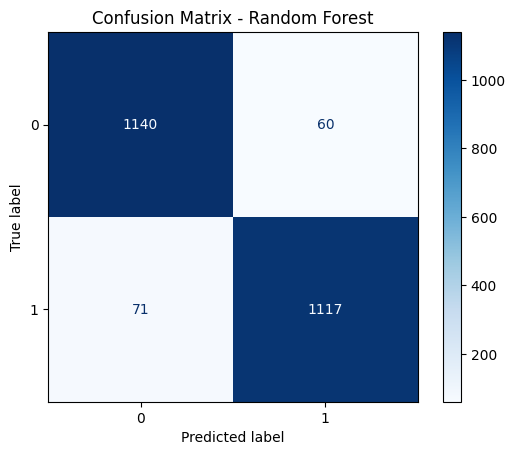

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# For Random Forest (you can do the same for other models)
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()


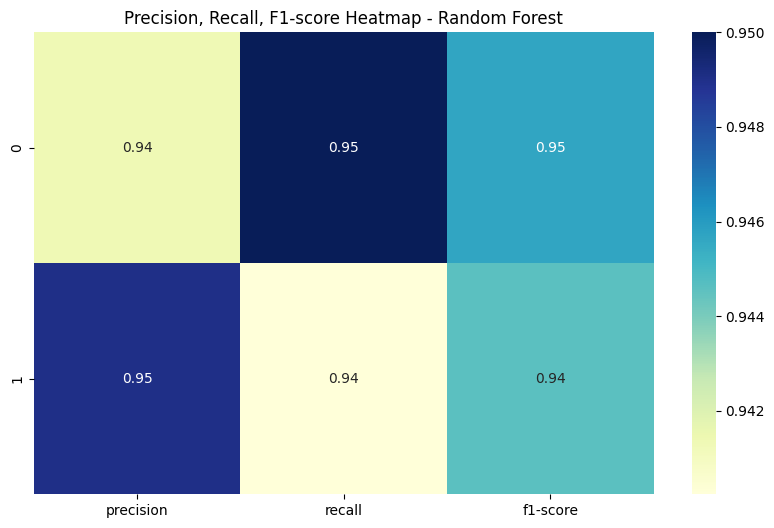

In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns

# Get classification report as a dictionary
report = classification_report(y_test, rf_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Filter out only precision, recall, f1-score
metrics = df_report[['precision', 'recall', 'f1-score']].iloc[:-3]  # remove avg rows

plt.figure(figsize=(10,6))
sns.heatmap(metrics, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Precision, Recall, F1-score Heatmap - Random Forest")
plt.show()
